## Simple Multi AI Agent Architecture

In [ ]:
# importing all necessary libraries
import os 

from typing import TypedDict ,Annotated , List , Literal

from langchain_core.messages import BaseMessage, SystemMessage, AIMessage ,HumanMessage
from langchain_core.tools import tool

from langchain_groq import ChatGroq

from langchain_tavily import TavilySearch

from langgraph.graph import StateGraph, END , MessagesState , START
from langgraph.prebuilt import create_react_agent, ToolNode ,tools_condition
from langgraph.checkpoint.memory import MemorySaver 

In [3]:
import os 
from dotenv import load_dotenv
load_dotenv()

os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

## Goal to be achieved

                        __Start__
                            |                          
                            V
                        RESEARCHER         (search for web info)

                            |
                            V 
                          WRITER           (summaries the research content)

                            |
                            V
                          __end__      

In [4]:
# intialising the Groq llm model
llm=ChatGroq(
    model="openai/gpt-oss-20b"
)

In [5]:
#defining the state
class AgentState(MessagesState):
    next_agent:str #tells whcih agents goes next 


#Creating simple tools

@tool
def search_web(query:str) -> str:
    """Search the web for information"""
    search = TavilySearch(max_results=2)
    result =search.invoke(query)
    return str(result)


@tool
def summary(content:str) -> str:
    """write the summary of the provided content"""
    #simple summary generation
    summary=f"Summary of the findings:\n\n{content[:500]}...."
    return summary

In [6]:
# defining multi Agents

def researcher(state:AgentState):
    """Research agent that searches for information. """

    messages= state["messages"]

    #adding system messages for context
    system_msg= SystemMessage(content="you're a research assistant.Use the serach_web to serach for the queries")

    researcher_llm =llm.bind_tools([search_web])
    response=researcher_llm.invoke([system_msg] + messages)

    # return the response and route to writer
    return {
        "messages":   [response],
        "next_agent":   "writer"
    }



#defingint the writer agent 
def writer(state:AgentState):
    """Wrtier agent the summarise the results"""

    messages = state["messages"]

    #adding a system messages
    system_msg = SystemMessage(content="you're a technical writer.Review the conversation and provide clear concise summarise")

    # simple completion of code without summaries
    # llm_with_tools= llm.bind_tools([summary])
    response=llm.invoke([system_msg] + messages)

    return {
        "messages":[response],
        "next_agent" : "end"
    }

In [7]:
# tools executer node
def  execute_tools(state:AgentState):
    """ Execute any pending tool calls"""

    messages = state["messages"]
    last_message =messages[-1]

    #check if there are tool calls to execute
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        #create tool node and execute
        tool_node = ToolNode([search_web,summary])
        response = tool_node.invoke(state)
        return response

    #no tool to execute
    return state

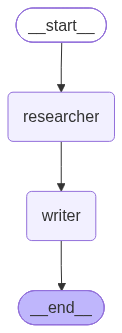

In [8]:
# creating a multi_agent graph
graph_builder = StateGraph(MessagesState)

#add node
graph_builder.add_node("researcher",researcher)
graph_builder.add_node("writer",writer)

#add edges
graph_builder.set_entry_point("researcher")
# graph_builder.add_edge( START ,"researcher")
graph_builder.add_edge("researcher" ,"writer")
graph_builder.add_edge("writer",END)

graph=graph_builder.compile()

graph

In [16]:
response=graph.invoke({"messages":"research about the chepeast flights from india to russia"})
response

{'messages': [HumanMessage(content='research about the chepeast flights from india to russia', additional_kwargs={}, response_metadata={}, id='940f2815-8fea-4c42-a82c-dfbedf5e4132'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to research cheapest flights from India to Russia. Likely need to browse web. We'll search.", 'tool_calls': [{'id': 'fc_fa662e41-9510-4151-b7bd-4c05b4a7ef18', 'function': {'arguments': '{"query":"cheapest flights India to Russia 2024"}', 'name': 'search_web'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 53, 'prompt_tokens': 150, 'total_tokens': 203, 'completion_time': 0.06686826, 'completion_tokens_details': {'reasoning_tokens': 22}, 'prompt_time': 0.045681136, 'prompt_tokens_details': None, 'queue_time': 0.315976362, 'total_time': 0.112549396}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_ef00694abe', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'mod

In [19]:
response["messages"][-1].pretty_print()

================================== Ai Message ==================================

**Cheapest Flights from India to Russia (2024‑2025)**  

| Airline | Typical Route | Cheapest One‑Way Fare (₹) | Notes |
|---------|---------------|---------------------------|-------|
| **Air India** | New Delhi (DEL) → Moscow (SVO) (1 stop, usually via Frankfurt or Istanbul) | 18 000 – 23 000 | Full‑service, good baggage allowance. |
| **Qatar Airways** | Delhi → Moscow (1 stop, Doha) | 17 000 – 21 000 | Frequent promotions, lounge access. |
| **Turkish Airlines** | Delhi → Moscow (1 stop, Istanbul) | 16 000 – 20 000 | Competitive fares, 1 kg free checked bag. |
| **Aeroflot** | Delhi → Moscow (1 stop, often via Doha or Istanbul) | 15 000 – 19 000 | Direct flights from Moscow to Delhi available. |
| **Etihad Airways** | Delhi → Moscow (1 stop, Abu Dhabi) | 18 000 – 22 000 | Good frequent‑flyer mileage. |
| **Pegasus Airlines** | Delhi → Moscow (1 stop, Istanbul) | 13 000 – 17 000 | Low‑fare carrier; wat

## Supervised Multi AI Agent Architecture

In [22]:
from typing import TypedDict , Annotated , List , Literal

from langchain_core.messages import BaseMessage , HumanMessage , AIMessage , SystemMessage
from langchain_core.prompts.chat import ChatPromptTemplate

from langchain_groq import ChatGroq

from langgraph.graph import StateGraph , MessagesState , END
from langgraph.checkpoint.memory import MemorySaver


import random
from datetime import datetime

In [21]:
#state defination
class SupervisorState(MessagesState):
    """ State for the multi-agent system """
    
    next_agent:str =""
    research_data: str = ""
    analysis: str =""
    final_report : str =""
    task_complete : bool = False
    current_task: str = ""


In [ ]:
# supervisor with groq llm
from langchain_core.prompts.chat import ChatPromptTemplate

def create_supervisor_chain():
    """ Creates the supervisor decision chain"""

    supervisor_prompt = ChatPromptTemplate([
        ("system", """ you are a supervisor managing a team of agensts:
        
        1.Researcher - Gather Information and data
        2.Analyst -- Analyse data and provides insights
        3.writer - creates report and summaries

        Based on the current state and conversation,decide which agent should work next.
        if the task is complete , respond with 'Done'.

        Current state:
        - has research data : {has_research}
        -has analysis : {has_analysis}
        - has report : {has_report}

        Responf with only the agent name {Researcher /Analyst /Writer } """),

        ("human","{task}")])

    return supervisor_prompt | llm

**Supervisor_Agent**

In [25]:
#next agent  Supervisor agent 
def supervisor_agent(state : SupervisorState) -> dict :
    """ SUpervisor decides next agent using Groq LLM """

    messages = state['messages']
    task = messages[-1].content if messages else "No tasks"

    #check what's been completed 
    has_research = bool(state.get("research_data", ""))
    has_analysis = bool(state.get("analysis_data",""))
    has_report = bool(state.get("final_report",""))\

    #get llm decision
    chain = create_supervisor_chain()
    decision = chain.invoke({
        "task":task ,
        "has_research" : has_research,
        "has_analysis" : has_analysis,
        "has_report" : has_report,

    })

    #parse decision
    decision_text = decision.content.strip().lower()

    # determine the next agent
    if "done" in decision_text or has_report:
        next_agent = "end"
        supervisor_msg =" SUpervisor : ALl task has been completed! great work team..."

    
    elif "researcher" in decision_text or not has_report:
        next_agent = "researcher"
        supervisor_msg =" SUpervisor : Lets start with research. Assigning to researcher..."

    elif "analyst" in decision_text or (has_report or not has_analysis):
        next_agent = "analyst"
        supervisor_msg =" SUpervisor : researchn has done. time for analysis .. Assining to analyst..."

    elif "writer" in decision_text or (has_analysis and not has_report):
        next_agent = "writer"
        supervisor_msg =" SUpervisor : Analysis complete. Lets create the report , assigning to writer..."

    else :
        next_agent="end"
        supervisor_msg =" SUpervisor : Task seems completed..."


    return {
        "messages" :[AIMessage(content=supervisor_msg)],
        "next_agent" : next_agent,
        "current_task" : task
    }
    








**Research_Agent**

In [ ]:
def researcher_agent(state:SupervisorState)-> dict:
    """ Researcher used groq to gather information """

    task = state.get("current_task" , "research topic")

    #research prompt
    researcher_prompt = f"""As a research specialist , provide comprehensive information about :{task}

    inlcude :
    1.key facts and background
    2.current trends or devfelopment
    3.important statistics or data points
    4.NOtable examples or case studies

    Be concise but thorough."""

    #get research from LLM 
    researcher_response = llm.invoke([HumanMessage(content=researcher_prompt)])
    researcher_data = researcher_response.content

    #create agent messages
    agent_message= f""" Researcher: I have completed the research on {task} .\n\n key findings:\n{researcher_data}
    
    """

    return {
        "messages" :[AIMessage(content=agent_message)],
        "researcher_data" : researcher_data,
        "next_agent" : next_agent,
    }

**Analyst_Agent**

In [31]:
def analyst_agent (state : SupervisorState) -> dict :
    """ Analyst used groq to analyse the research"""

    researcher_data =state.get("research_data","")
    task = state.get("current_task","")
    
    #create anlaysis prompt
    analysis_prompt = f""" As a data analyst ,analyse this reserach data and provide insights:

    Reserach data:
    {researcher_data}

    Provide :
    1.key insights and patterns
    2.strategic implication
    3.risks and oppportunities
    4.Recommendations


    focus on actionanle insights related to {task}"""

    #get research from LLM 
    analysis_response = llm.invoke([HumanMessage(content=analysis_prompt)])
    analysis =analysis_response.content

    #create agent messages
    agent_message= f""" Analyst: I have completed the analysis on {task} .\n\n Top findings :\n {analysis}
    
    """

    return {
        "messages" :[AIMessage(content=agent_message)],
        "researcher_data" : analysis,
        "next_agent" : "supervisor",
    }

**Agent 3 : Writer**

In [35]:
def writer_agent(state:SupervisorState) -> dict:
    """ writer users groq to create final report """

    research_data = state.get("research_data")
    analysis = state.get("analysis","")
    task = state.get("current_task","")

    #create writing prompt
    writing_prompt = f""" as a professional writer , create an executive report based on:

    Task :{task}

    Reserch finding:
    {research_data[:1000]} 
    
    Analysis:
    {analysis[:1000]}

    create a well structured report with :
    1.Executive summary
    2.key finidngs
    3.Analysis and insights 
    4.recommendations

    keep it professional and concise.
    """

    #get analysis from LLM
    report_response = llm.invoke([HumanMessage(content=writing_prompt)])
    report =report_response.content

    #create final formtted report 
    final_report =f"""
    FINAL REPORT
    {"="*50}
    Generated : {datetime.now().strftime("%y-%m-%d %H:%M")}

    Topic : {task}
    {"="*50}

    {report}

    {"=" * 50}
    Report compiled by Multi Agent AI system powered by groq
    """

    return {
        "messages": [AIMessage(content = f"Writer: Report complete! see below for the full document")],
        "final_report" : final_report,
        "next_agent" : 'supervisor',
        "task_complete" : True

    }



In [36]:
def router(state : SupervisorState)-> Literal['supervisor',"researcher", "analyst_agent","writer","__end__"]:
    """ Router to next agent based on state """
    
    next_agent = state.get("next_agent","supervisor")

    if next_agent == "end" or state.get("task_complete", False):
        return END

    if next_agent in ['supervisor',"researcher", "analyst_agent","writer"]:
        return next_agent
    
    return "supervisor"